<a href="https://colab.research.google.com/github/JeanHenriqueSz/ADBD-ATIVIDADE-03/blob/main/ADBD_ATIVIDADE_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [11]:

#1 BAIXAR E CARREGAR DATASET

url = "https://github.com/alanjones2/dataviz/raw/master/londonweather.csv"
df = pd.read_csv(url)

print("Dataset carregado com sucesso!")
df.head()

Dataset carregado com sucesso!


,Year,Month,Tmax,Tmin,Rain,Sun
0,1957,1,8.7,2.7,39.5,53.0
1,1957,2,9.0,2.9,69.8,64.9
2,1957,3,13.9,5.7,25.4,96.7
3,1957,4,14.2,5.2,5.7,169.6
4,1957,5,16.2,6.5,21.3,195.0


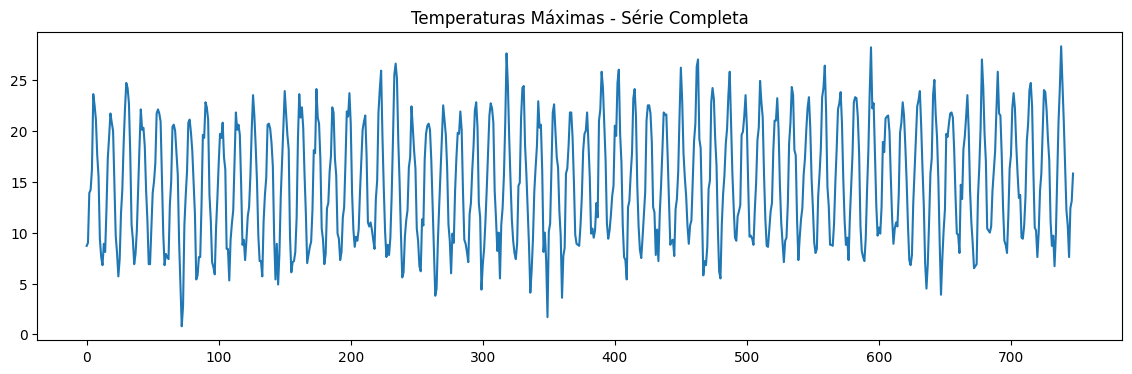

In [3]:
#2 VISUALIZAÇÃO SIMPLES

df['Tmax'].plot(figsize=(14,4), title="Temperaturas Máximas - Série Completa")
plt.show()

In [14]:
#3 ÚLTIMOS 10 ANOS

ultimo_ano = df['Year'].max()
anos_ultimos_10 = list(range(ultimo_ano - 9, ultimo_ano + 1))

df_10anos = df[df['Year'].isin(anos_ultimos_10)]

print("Último ano registrado:", ultimo_ano)
print("Anos selecionados:", anos_ultimos_10)


Último ano registrado: 2019
Anos selecionados: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
Último ano 2019


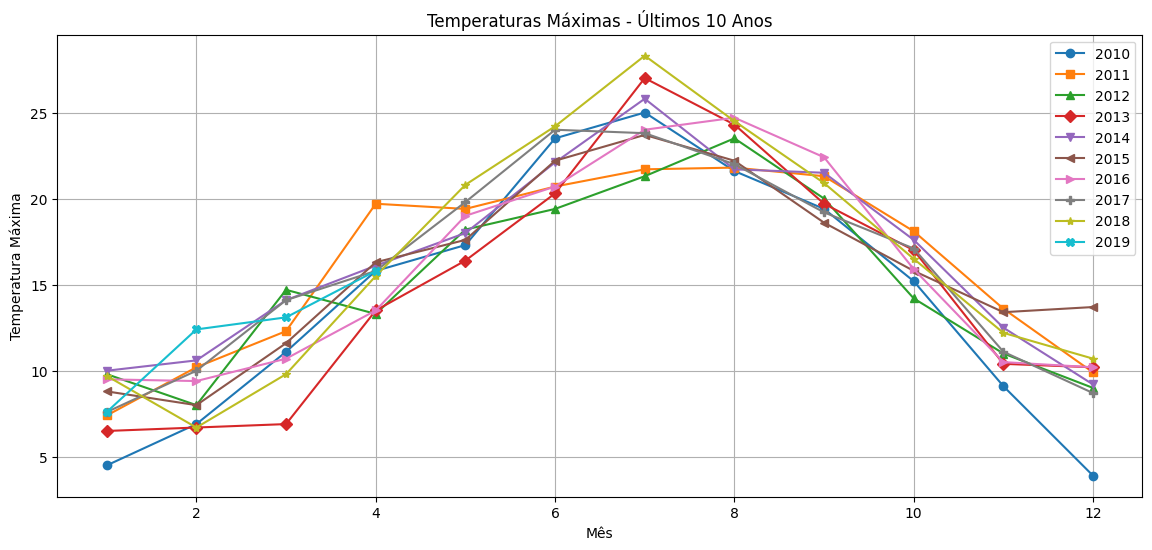

In [5]:
#4,5 SÉRIE SOBREPOSTA

plt.figure(figsize=(14,6))

cores = plt.cm.tab10(np.linspace(0,1,10))
marcadores = ['o','s','^','D','v','<','>','P','*','X']

for i, year in enumerate(anos_ultimos_10):
    dados = df_10anos[df_10anos['Year'] == year]
    plt.plot(dados['Month'], dados['Tmax'],
             label=str(year),
             marker=marcadores[i],
             color=cores[i])

plt.title("Temperaturas Máximas - Últimos 10 Anos")
plt.xlabel("Mês")
plt.ylabel("Temperatura Máxima")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
#6 ANÁLISE + MÊS/ANO MAIS QUENTE

pico = df_10anos.loc[df_10anos['Tmax'].idxmax()]
print("Pico de temperatura nos últimos 10 anos:")
print(pico)

Pico de temperatura nos últimos 10 anos:
Year     2018.0
Month       7.0
Tmax       28.3
Tmin       16.4
Rain       14.8
Sun       272.5
Name: 738, dtype: float64


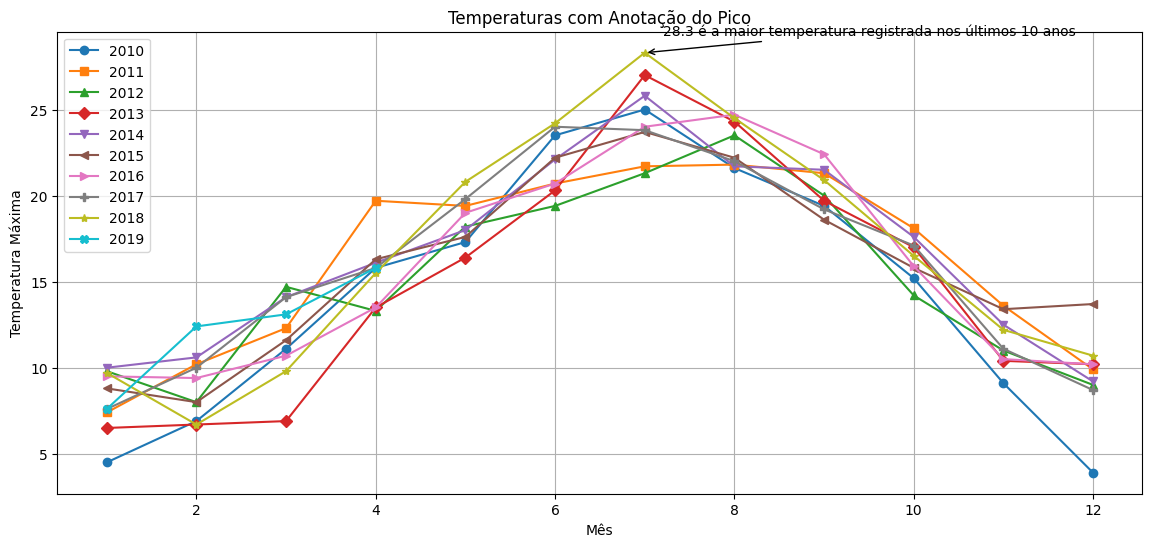

In [7]:
#7 ADICIONAR ANOTAÇÃO

plt.figure(figsize=(14,6))

for i, year in enumerate(anos_ultimos_10):
    dados = df_10anos[df_10anos['Year'] == year]
    plt.plot(dados['Month'], dados['Tmax'],
             label=str(year),
             marker=marcadores[i],
             color=cores[i])

plt.annotate(
    f"{pico['Tmax']} é a maior temperatura registrada nos últimos 10 anos",
    xy=(pico['Month'], pico['Tmax']),
    xytext=(pico['Month']+0.2, pico['Tmax']+1),
    arrowprops=dict(facecolor='black', arrowstyle='->')
)

plt.title("Temperaturas com Anotação do Pico")
plt.xlabel("Mês")
plt.ylabel("Temperatura Máxima")
plt.legend()
plt.grid(True)
plt.show()

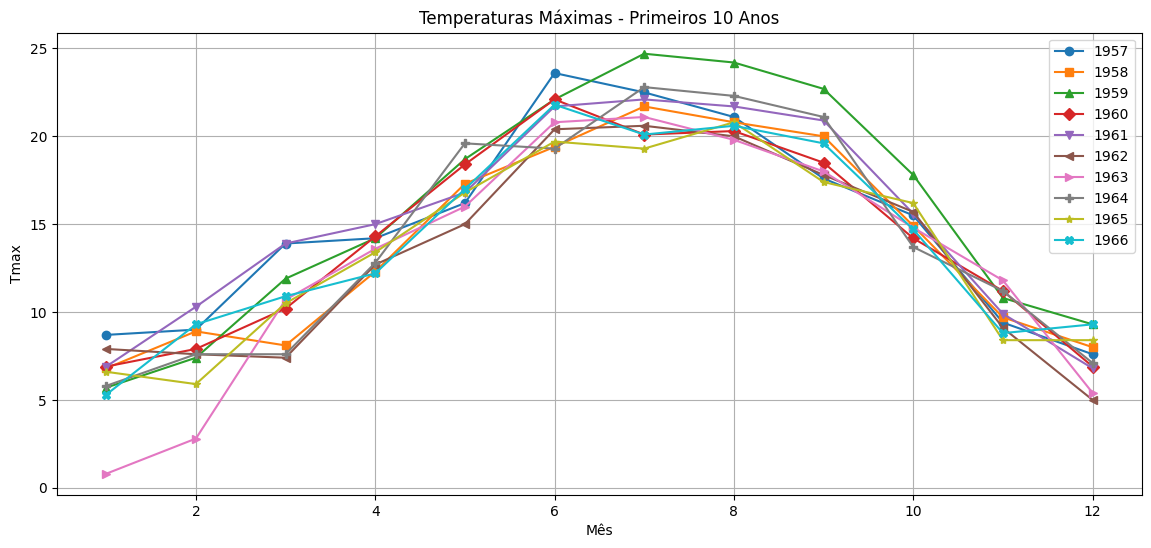

In [8]:
#8 PRIMEIROS 10 ANOS


primeiros_anos = sorted(df['Year'].unique())[:10]
df_primeiros10 = df[df['Year'].isin(primeiros_anos)]

plt.figure(figsize=(14,6))
for i, year in enumerate(primeiros_anos):
    dados = df_primeiros10[df_primeiros10['Year'] == year]
    plt.plot(dados['Month'], dados['Tmax'],
             label=str(year),
             marker=marcadores[i % len(marcadores)],
             color=cores[i % len(cores)])

plt.title("Temperaturas Máximas - Primeiros 10 Anos")
plt.xlabel("Mês")
plt.ylabel("Tmax")
plt.legend()
plt.grid(True)
plt.show()

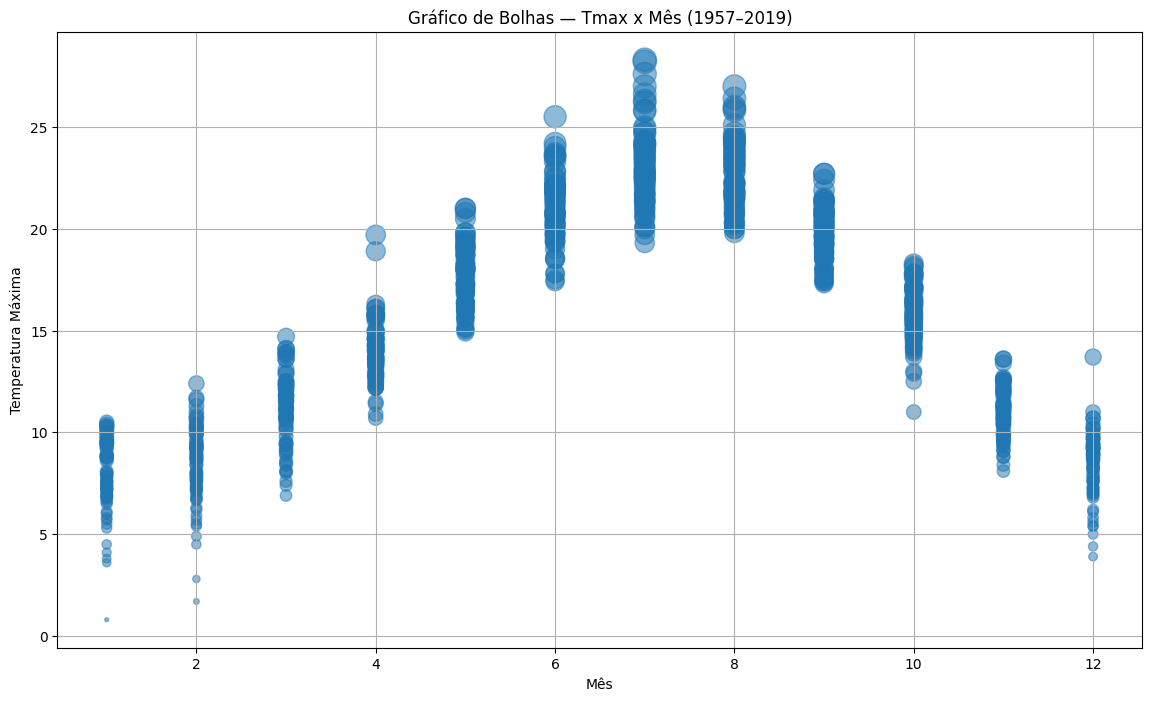

In [9]:
#GRÁFICO DE BOLHAS

plt.figure(figsize=(14,8))
plt.scatter(
    df['Month'],
    df['Tmax'],
    s=df['Tmax']*10,   # tamanho da bolha
    alpha=0.5
)
plt.title("Gráfico de Bolhas — Tmax x Mês (1957–2019)")
plt.xlabel("Mês")
plt.ylabel("Temperatura Máxima")
plt.grid(True)
plt.show()
